Loaded fold 0 train partition : (12537, 81)
  risky_upgrade (clustering target) : 1,094
  safe_upgrade  (reference, fold 0 train only) : 11,443
Clustering features : 22
  [Note: original paper used 16 variables; this fold uses 22 after VIF threshold=5 — see NB03/NB03b fold-specific output.]
Minimum cluster size : 55 (5% of sample)

Feature matrix shape : (1094, 22)

[Step 1] K selection (K=2 to 8), fold 0...
  Selection pool: K >= 3 AND min cluster size >= 55
  K=2  sil=0.3528  dbi=1.7153  min_cluster=203  eligible=False  [K < MIN_K]
  K=3  sil=0.3667  dbi=1.5627  min_cluster=35  eligible=False  [min cluster n=35 < 55]
  K=4  sil=0.1828  dbi=1.7937  min_cluster=35  eligible=False  [min cluster n=35 < 55]
  K=5  sil=0.1975  dbi=1.7883  min_cluster=35  eligible=False  [min cluster n=35 < 55]
  K=6  sil=0.1838  dbi=1.6851  min_cluster=12  eligible=False  [min cluster n=12 < 55]
  K=7  sil=0.1748  dbi=1.6598  min_cluster=12  eligible=False  [min cluster n=12 < 55]
  K=8  sil=0.1780  dbi=1.

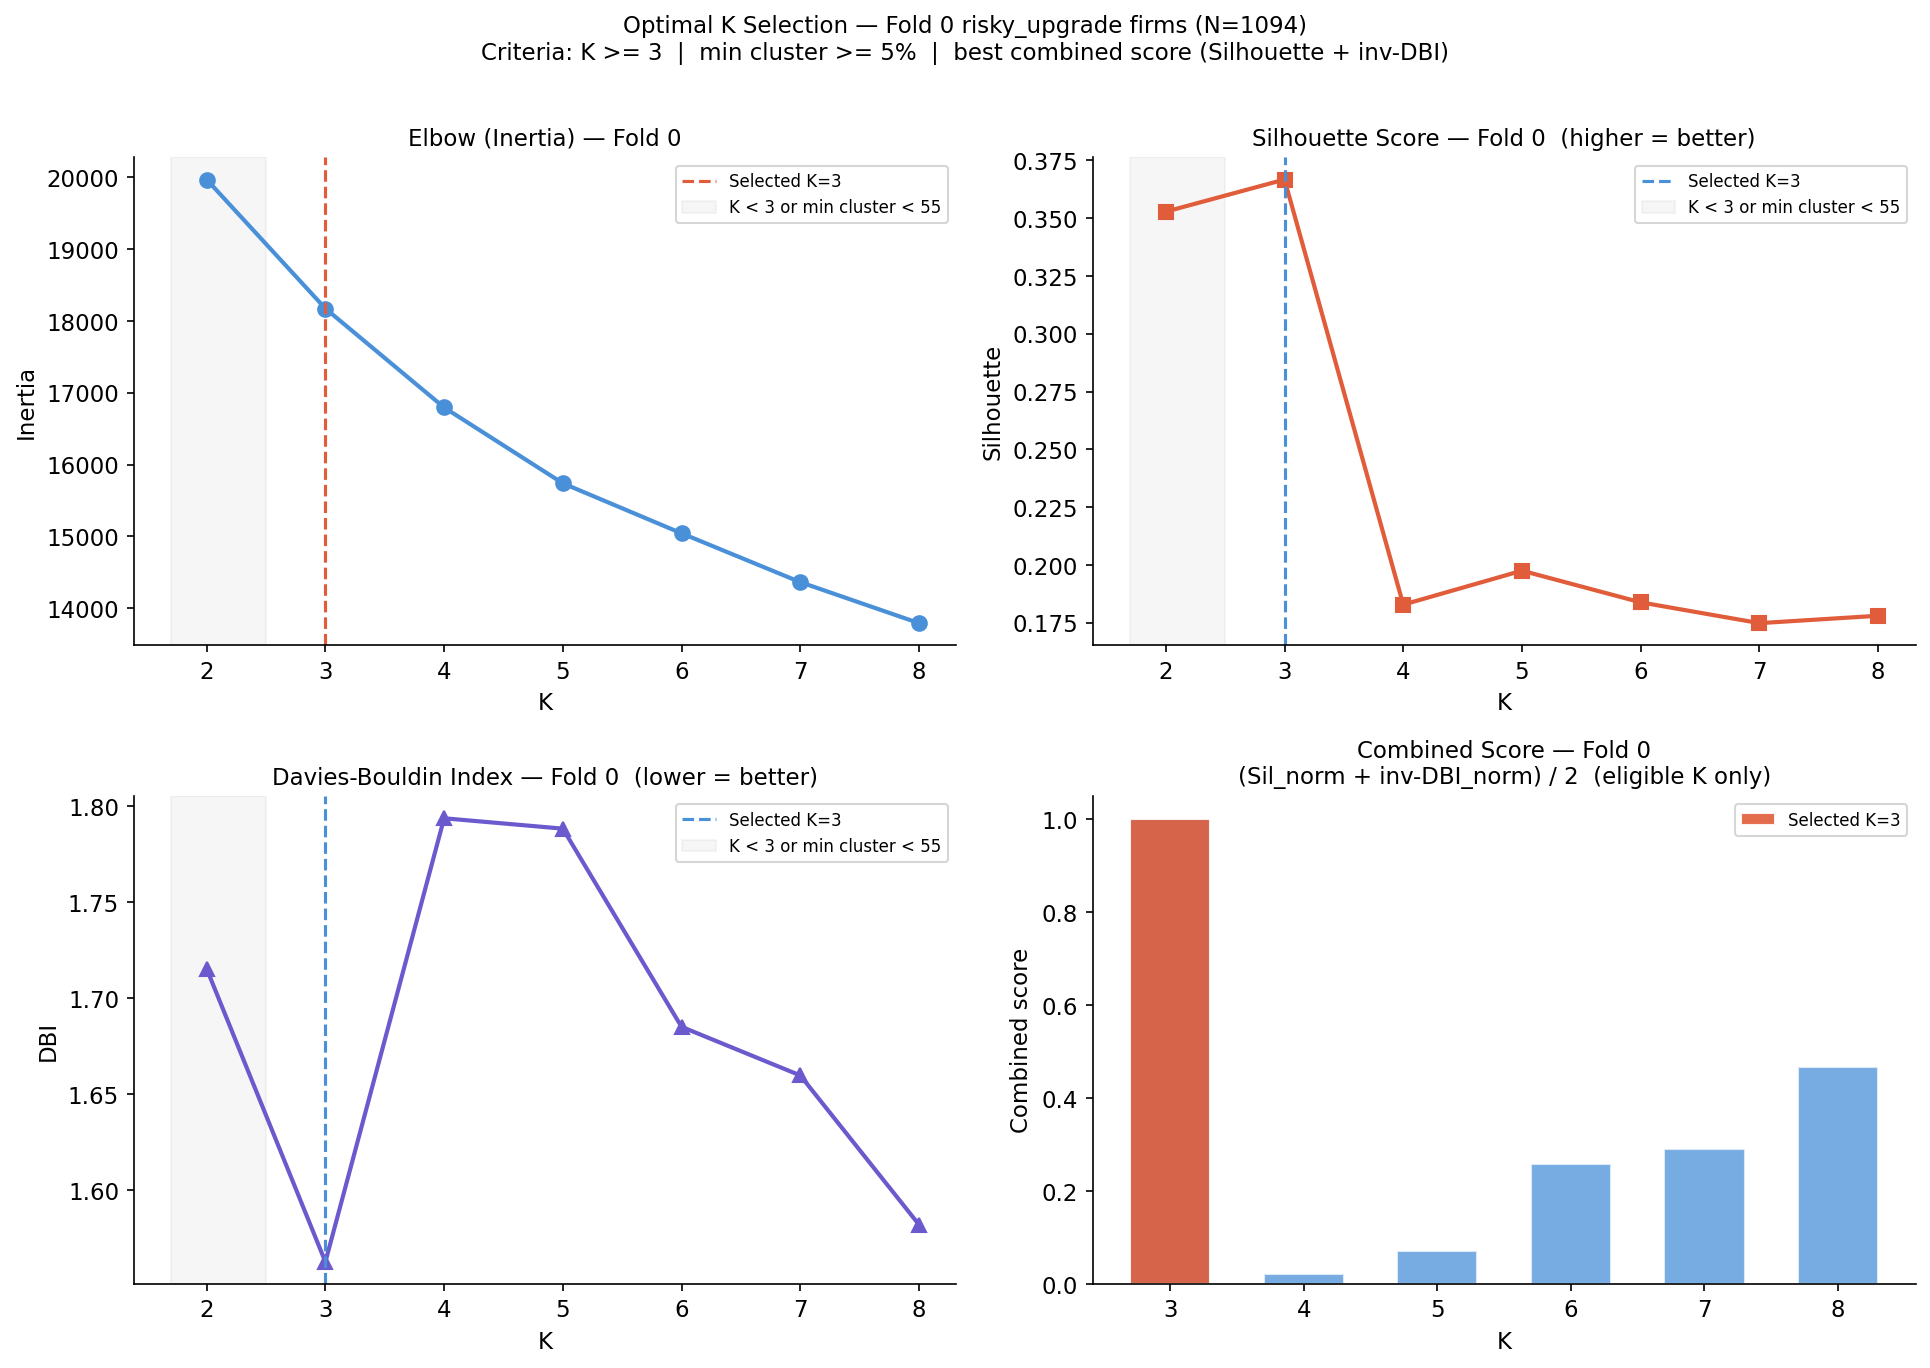

Figure saved: NB05_01_elbow_silhouette_fold0.png

[Step 2] Fitting K-Means with K = 3 (fold 0)...
Cluster sizes:
cluster
0     35
1    862
2    197

  This may occur due to random initialisation variance.
  Consider increasing RANDOM_SEED or n_init, or reducing MIN_K.

[Step 3] Computing cluster profiles (fold 0)...

Cluster profiles (relative deviation from fold-0-train safe cohort median):

  Cluster 0  (n=35)
    Attr52                              rel_dev=-0.909  (cluster=0.0229  safe=0.2514)
    Attr49                              rel_dev=+nan  (cluster=0.0231  safe=0.0000)
    Attr38                              rel_dev=+1.034  (cluster=0.9638  safe=0.4738)
    working_capital_to_assets           rel_dev=+6.012  (cluster=0.6818  safe=0.0972)
    Attr30                              rel_dev=-1.767  (cluster=-0.2131  safe=0.2777)
    Attr25                              rel_dev=+0.458  (cluster=0.3348  safe=0.2296)
    Attr13                              rel_dev=+0.900  (cluster=0.06

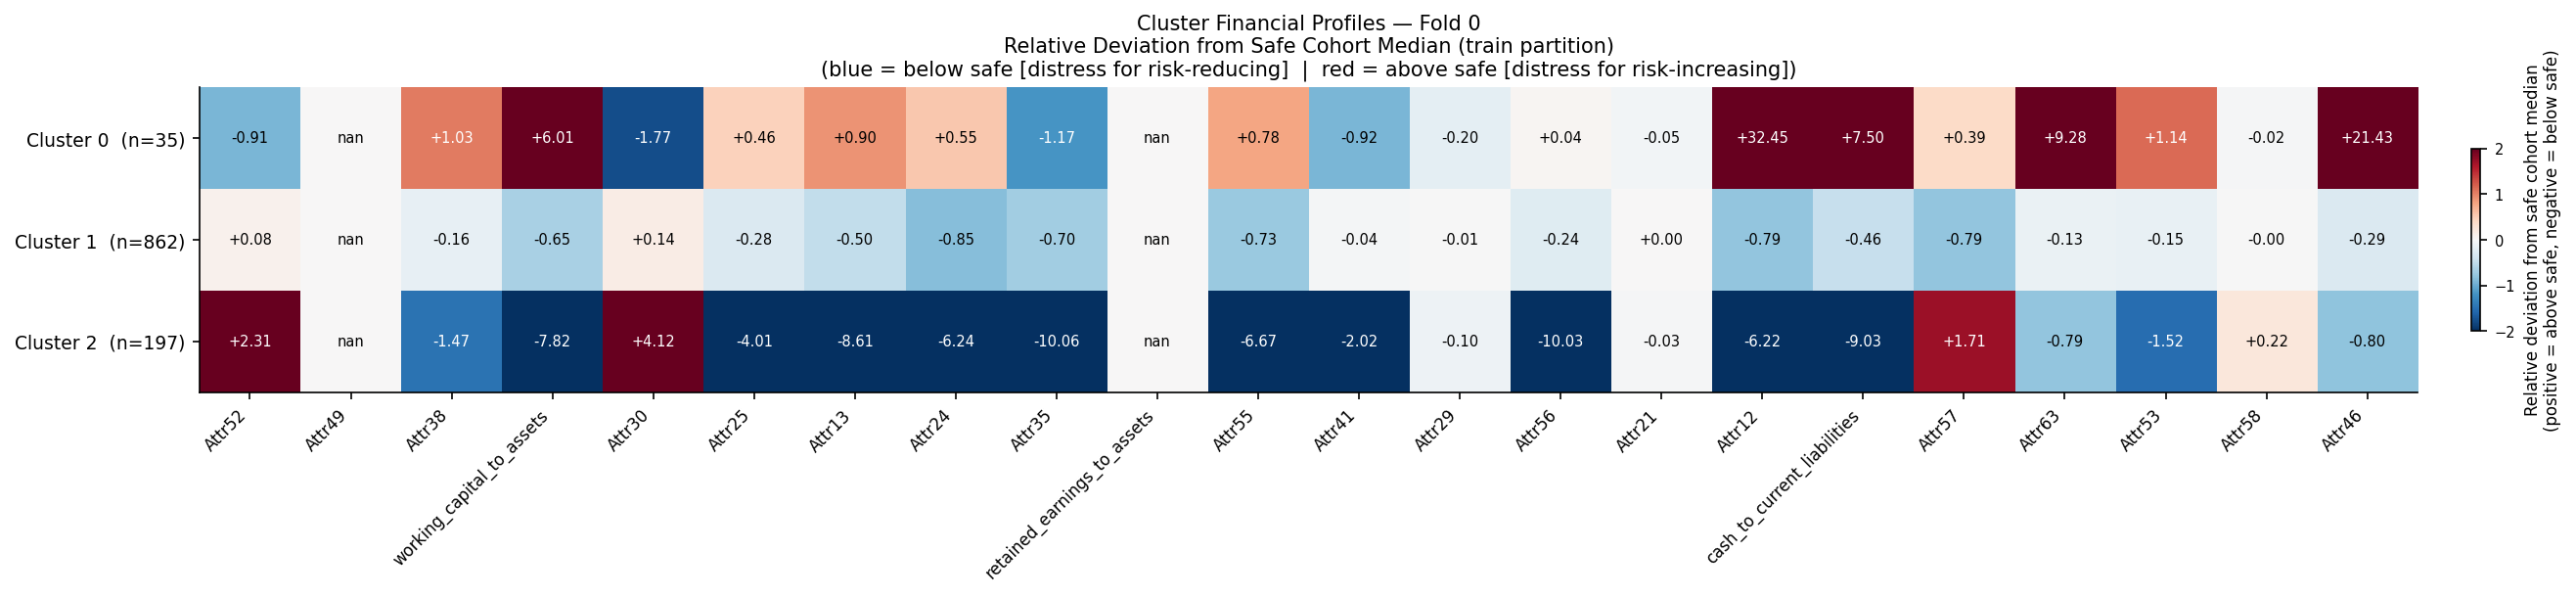

Figure saved: NB05_02_cluster_profiles_fold0.png

[Figure 3] PCA cluster scatter (fold 0)


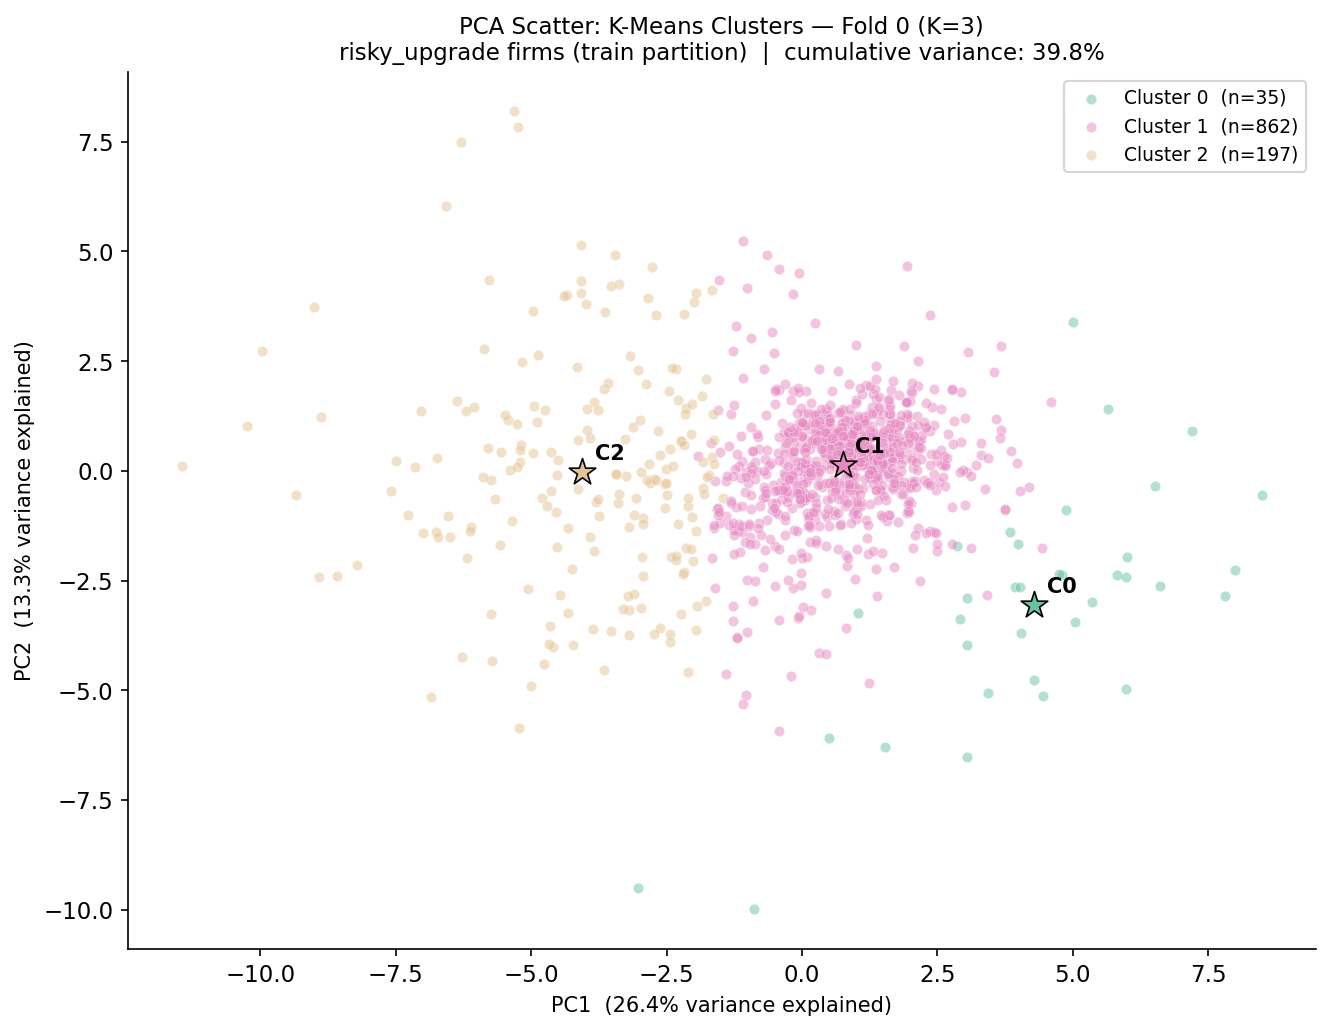

Figure saved: NB05_03_cluster_pca_fold0.png

[Figure 4] Box plots — top 6 discriminating variables (fold 0)
  Top 6 discriminating variables (by F-statistic):
    Attr46                              F=1343.22
    Attr63                              F=636.62
    working_capital_to_assets           F=434.22
    Attr30                              F=359.63
    Attr38                              F=323.15
    Attr25                              F=320.29


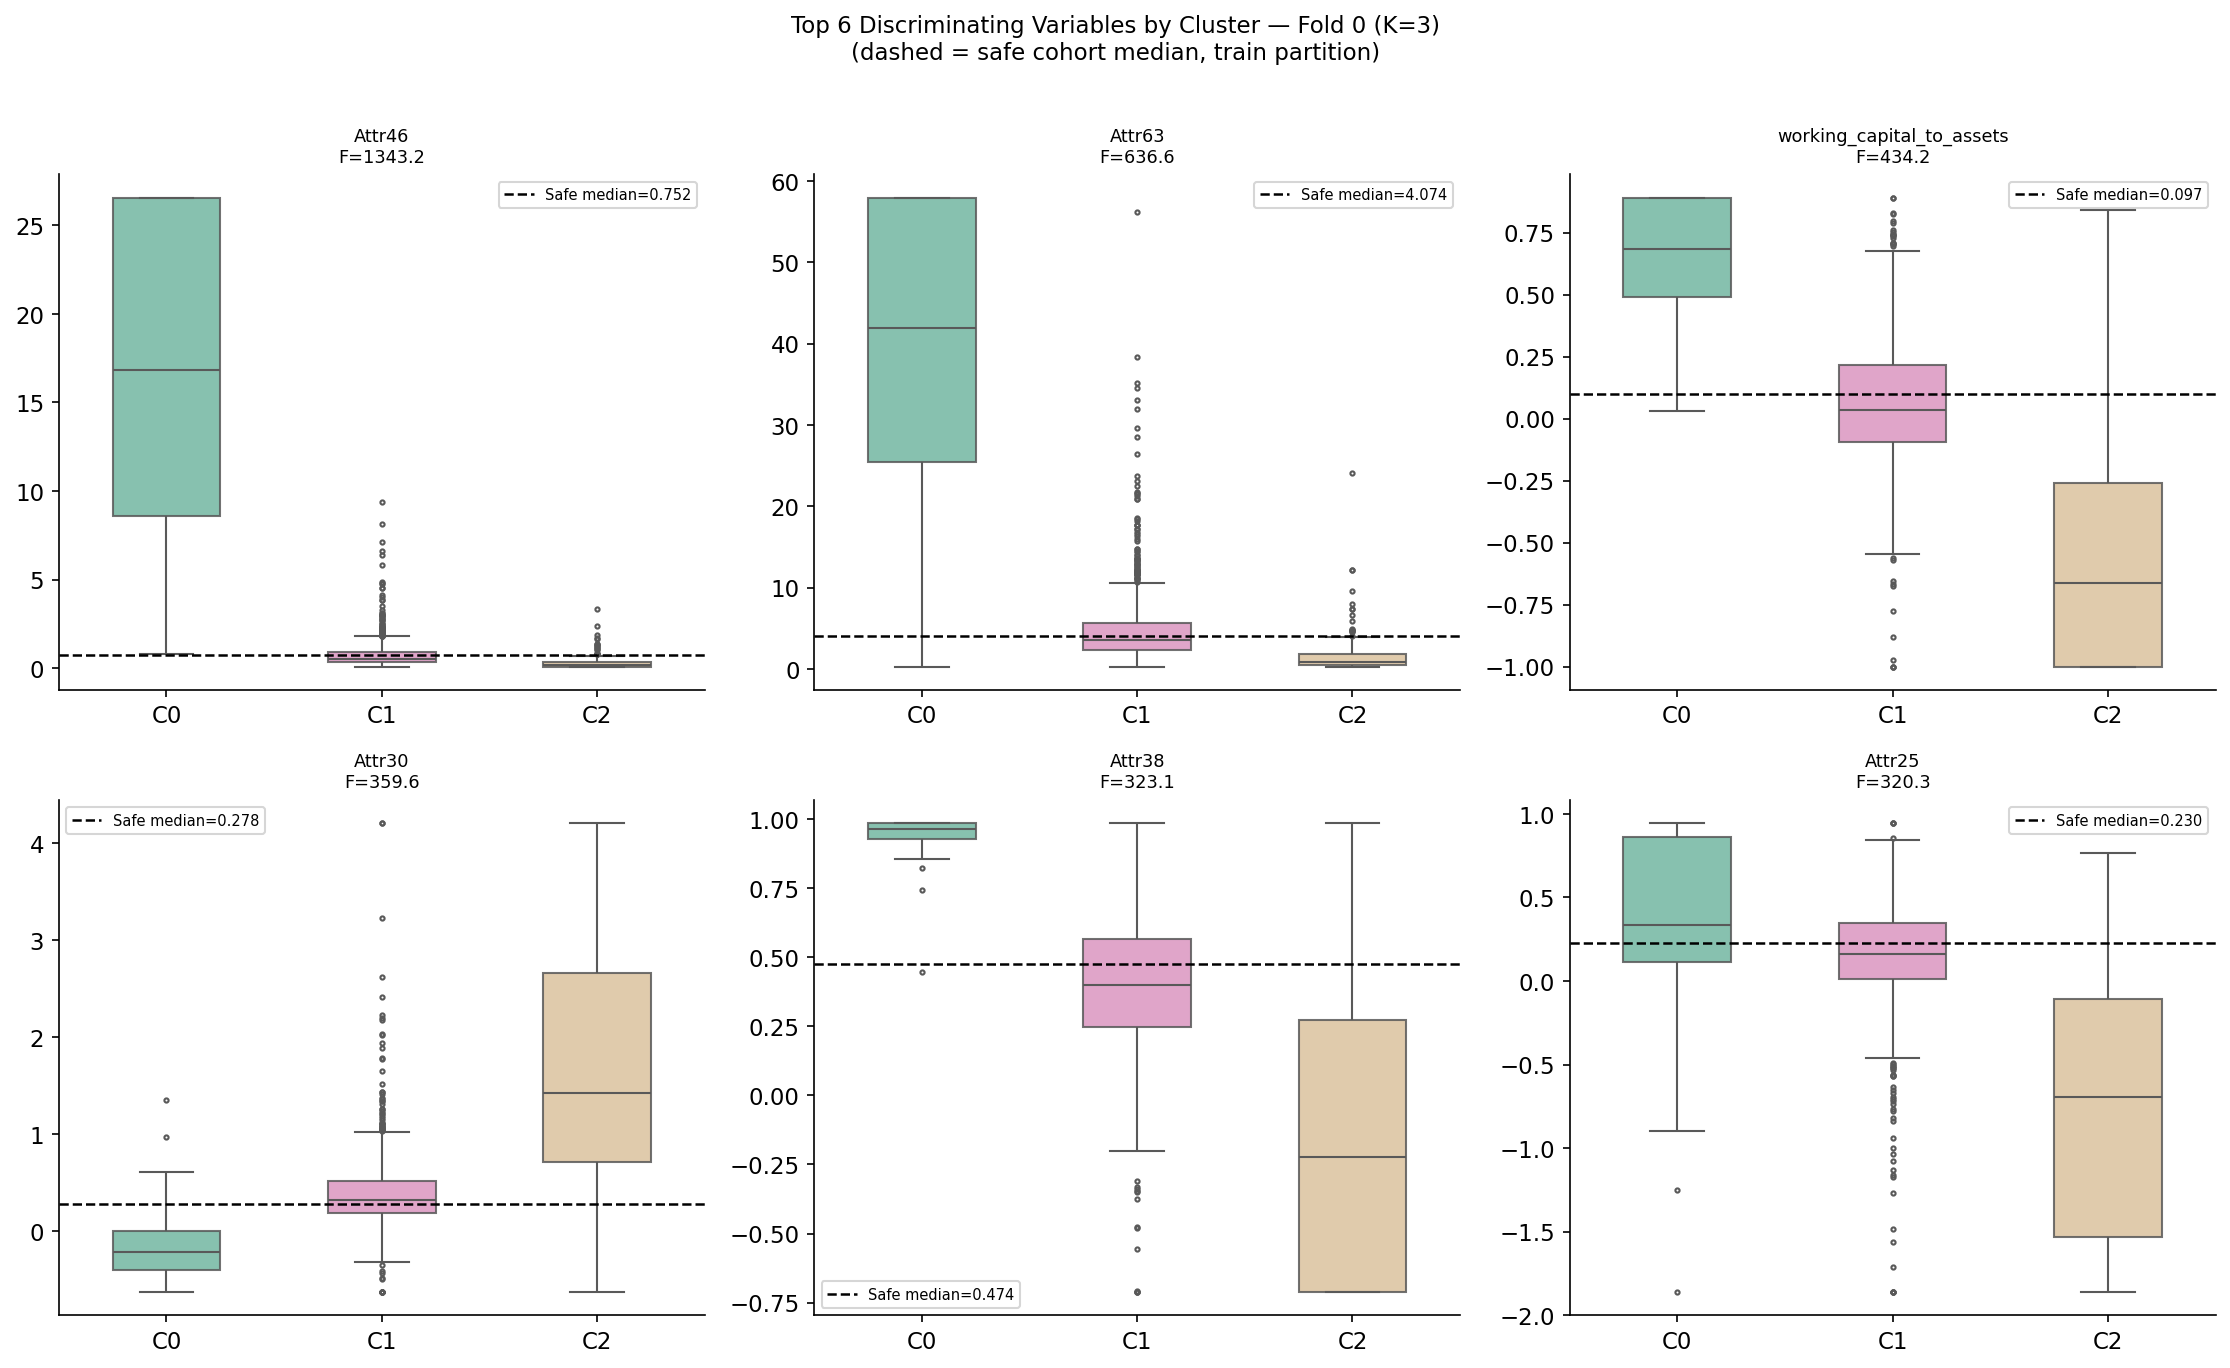

Figure saved: NB05_04_cluster_boxplots_fold0.png

NB05 SUMMARY — FOLD 0 (TRAIN PARTITION)
Optimal K selected         : 3
  Silhouette (K=3)        : 0.3667
  Davies-Bouldin (K=3)    : 1.5627
  Min cluster size (K=3)  : 35 (threshold=55)
  [Paper reference, full-sample run: K=4, Silhouette=0.1395, Davies-Bouldin=1.9309]

Cluster summary:
  Cluster 0  n=  35  dominant signals: ['Attr35', 'Attr41', 'Attr29']
  Cluster 1  n= 862  dominant signals: ['Attr24', 'Attr57', 'Attr12']
  Cluster 2  n= 197  dominant signals: ['Attr35', 'Attr56', 'cash_to_current_liabilities']

K selection rationale (for paper methods section):
  K was selected from the range [3, 8] using two
  complementary internal validity indices — the Silhouette
  coefficient (Rousseeuw, 1987) and the Davies-Bouldin index
  (Davies & Bouldin, 1979) — normalised and averaged into a
  combined score. An additional constraint required each cluster
  to contain at least 5% of the sample (n >= 55)
  to ensure sufficient observations

In [1]:
# ============================================================================
# NB05_clustering.ipynb  —  Nested CV Version, Step 1: fold 0
#
# Study 2: K-Means clustering of risky_upgrade firms
#
# ----------------------------------------------------------------------------
# WHAT CHANGED FROM THE ORIGINAL VERSION
# ----------------------------------------------------------------------------
# Original version read the full upgrade_cohort.parquet (N = 15,684) and
# NB03b_variable_map.csv (16 variables).
#
# This version reads fold 0's outer-training partition and
# NB03b_variable_map_fold0.csv (22 variables — see NB03/NB03b fold 0
# output, VIF threshold=5). Because `safe` is derived from the same
# fold-0-train-only `cohort`, safe_medians below are computed EXCLUSIVELY
# from fold 0's training-partition safe_upgrade firms (n=11,443) — no
# information from fold 0's outer-holdout partition enters the cluster
# profiling reference point. This matters because safe_medians serves as
# the baseline against which each cluster's distress signature is measured
# (Section 3, rel_dev); using holdout-derived medians here would leak
# holdout information into a quantity that shapes the discovered cluster
# labels, which NB07 will later validate against that same holdout set.
#
# Method (unchanged from original):
#   K-Means clustering is applied exclusively to risky_upgrade firms to
#   identify distinct financial distress profiles that the evaluator's
#   upgrade decision overlooked.
#
#   Optimal K selection criteria (all three must be satisfied):
#   (1) K >= MIN_K (minimum 3 for judgment factor interpretability)
#   (2) Minimum cluster size >= MIN_CLUSTER_PCT of sample (5%)
#       — prevents trivially small clusters from inflating silhouette
#   (3) Best combined score: Silhouette (higher = better) +
#       Davies-Bouldin Index (lower = better, normalised to [0,1])
#       — two complementary metrics that agree on the same K
#
# Reference: Tibshirani et al. (2001); Davies & Bouldin (1979)
#
# Input  : data/processed/fold_0/upgrade_cohort_fold0.parquet
#           -> filtered to outer_split == "train"
#          results/tables/NB03b_variable_map_fold0.csv  (22 variables)
# Outputs:
#   results/tables/NB05_01_cluster_profiles_fold0.csv
#   results/tables/NB05_02_cluster_assignments_fold0.csv
#   results/tables/NB05_03_k_selection_fold0.csv
#   results/figures/NB05_01_elbow_silhouette_fold0.png
#   results/figures/NB05_02_cluster_profiles_fold0.png
#   results/figures/NB05_03_cluster_pca_fold0.png
#   results/figures/NB05_04_cluster_boxplots_fold0.png
# ============================================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy import stats

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi"       : 150,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.size"        : 11,
    "font.family"      : "DejaVu Sans",
})

PROC_DIR  = "../data/processed/"
FIG_DIR   = "../results/figures/"
TABLE_DIR = "../results/tables/"

os.makedirs(FIG_DIR,   exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

RANDOM_SEED      = 42
FOLD_ID          = 0   # will become a loop variable in the next version
MIN_K            = 3
MAX_K            = 8
MIN_CLUSTER_PCT  = 0.05


# ── Load fold 0 train partition + NB03b's deduplicated variable list ────────

fold_cohort_path = os.path.join(PROC_DIR, f"fold_{FOLD_ID}", f"upgrade_cohort_fold{FOLD_ID}.parquet")
cohort_full_fold = pd.read_parquet(fold_cohort_path)
cohort = cohort_full_fold[cohort_full_fold["outer_split"] == "train"].copy()

var_map_path = os.path.join(TABLE_DIR, f"NB03b_variable_map_fold{FOLD_ID}.csv")
var_map    = pd.read_csv(var_map_path, index_col=0)
final_vars = var_map.index.tolist()

risky = cohort[cohort["group"] == "risky_upgrade"].copy()
safe  = cohort[cohort["group"] == "safe_upgrade"].copy()

N_RISKY       = len(risky)
MIN_CLUSTER_N = int(np.ceil(N_RISKY * MIN_CLUSTER_PCT))

print(f"Loaded fold {FOLD_ID} train partition : {cohort.shape}")
print(f"  risky_upgrade (clustering target) : {N_RISKY:,}")
print(f"  safe_upgrade  (reference, fold {FOLD_ID} train only) : {len(safe):,}")
print(f"Clustering features : {len(final_vars)}")
print(f"  [Note: original paper used 16 variables; this fold uses "
      f"{len(final_vars)} after VIF threshold=5 — see NB03/NB03b fold-specific output.]")
print(f"Minimum cluster size : {MIN_CLUSTER_N} ({MIN_CLUSTER_PCT*100:.0f}% of sample)")

safe_medians = safe[final_vars].median()


# ── Prepare feature matrix ────────────────────────────────────────────────────

X_risky  = risky[final_vars].copy().fillna(risky[final_vars].median())
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_risky)

print(f"\nFeature matrix shape : {X_scaled.shape}")


# ── K selection — Silhouette + Davies-Bouldin + min cluster size ──────────────

print(f"\n[Step 1] K selection (K=2 to {MAX_K}), fold {FOLD_ID}...")
print(f"  Selection pool: K >= {MIN_K} AND min cluster size >= {MIN_CLUSTER_N}")

K_RANGE   = range(2, MAX_K + 1)
k_results = []

for k in K_RANGE:
    km   = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=50)
    lbl  = km.fit_predict(X_scaled)
    sil  = silhouette_score(X_scaled, lbl)
    dbi  = davies_bouldin_score(X_scaled, lbl)
    ine  = km.inertia_
    sizes = np.bincount(lbl)
    min_size = sizes.min()
    eligible = (k >= MIN_K) and (min_size >= MIN_CLUSTER_N)

    k_results.append({
        "K"           : k,
        "inertia"     : round(ine, 1),
        "silhouette"  : round(sil, 4),
        "davies_bouldin": round(dbi, 4),
        "min_cluster_n": int(min_size),
        "eligible"    : eligible,
    })

    flag = ""
    if k < MIN_K:
        flag = "  [K < MIN_K]"
    elif min_size < MIN_CLUSTER_N:
        flag = f"  [min cluster n={min_size} < {MIN_CLUSTER_N}]"
    print(f"  K={k}  sil={sil:.4f}  dbi={dbi:.4f}  "
          f"min_cluster={min_size}  eligible={eligible}{flag}")

k_df = pd.DataFrame(k_results).set_index("K")

eligible_df = k_df[k_df["eligible"]].copy()

if len(eligible_df) == 0:
    print(f"\nWARNING: No K satisfies all criteria (fold {FOLD_ID}).")
    print(f"  All K >= {MIN_K} have at least one cluster smaller than {MIN_CLUSTER_N}.")
    print(f"  Fallback: selecting from K >= {MIN_K} ignoring min_cluster_size constraint.")
    print(f"  Rationale: small clusters reflect genuine extreme distress cases")
    print(f"  that are analytically informative despite their size.")
    eligible_df = k_df[k_df.index >= MIN_K].copy()

sil_min, sil_max = eligible_df["silhouette"].min(), eligible_df["silhouette"].max()
dbi_min, dbi_max = eligible_df["davies_bouldin"].min(), eligible_df["davies_bouldin"].max()

eligible_df["sil_norm"] = (eligible_df["silhouette"] - sil_min) / (sil_max - sil_min + 1e-9)
eligible_df["dbi_norm"] = 1 - (eligible_df["davies_bouldin"] - dbi_min) / (dbi_max - dbi_min + 1e-9)
eligible_df["combined_score"] = (eligible_df["sil_norm"] + eligible_df["dbi_norm"]) / 2

inertia_arr = np.array(k_df["inertia"].tolist())
d2          = np.diff(np.diff(inertia_arr))
elbow_k     = list(K_RANGE)[np.argmax(d2) + 1]

if k_df["eligible"].sum() == 0:
    if elbow_k >= MIN_K:
        OPTIMAL_K = elbow_k
        print(f"\n  Fallback selection: using Elbow K = {OPTIMAL_K}")
        print(f"  (Elbow is preferred over combined score when min_cluster_size")
        print(f"   cannot be satisfied, as it is determined purely from inertia")
        print(f"   without dependence on cluster size distribution.)")
    else:
        OPTIMAL_K = int(eligible_df["combined_score"].idxmax())
        print(f"\n  Fallback selection: using combined score K = {OPTIMAL_K}")
else:
    OPTIMAL_K = int(eligible_df["combined_score"].idxmax())
    print(f"\n  Selected K = {OPTIMAL_K} (all criteria satisfied)")

out_path = os.path.join(TABLE_DIR, f"NB05_03_k_selection_fold{FOLD_ID}.csv")
k_df.to_csv(out_path)
print(f"  Saved K selection table: {out_path}")


# ── Figure 1: K selection — 2×2 panel ────────────────────────────────────────

print(f"\n[Figure 1] K selection plots (fold {FOLD_ID})")

ks   = list(K_RANGE)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
ax_ine, ax_sil, ax_dbi, ax_comb = axes.flatten()

def shade_excluded(ax, ks):
    ax.axvspan(min(ks) - 0.3, MIN_K - 0.5, alpha=0.07, color="grey",
               label=f"K < {MIN_K} or min cluster < {MIN_CLUSTER_N}")

ax_ine.plot(ks, k_df["inertia"], "o-", color="#4A90D9", linewidth=2, markersize=7)
ax_ine.axvline(OPTIMAL_K, color="#E05C3A", linestyle="--", linewidth=1.5,
               label=f"Selected K={OPTIMAL_K}")
shade_excluded(ax_ine, ks)
ax_ine.set_title(f"Elbow (Inertia) — Fold {FOLD_ID}", fontsize=11)
ax_ine.set_xlabel("K")
ax_ine.set_ylabel("Inertia")
ax_ine.set_xticks(ks)
ax_ine.legend(fontsize=8)

ax_sil.plot(ks, k_df["silhouette"], "s-", color="#E05C3A", linewidth=2, markersize=7)
ax_sil.axvline(OPTIMAL_K, color="#4A90D9", linestyle="--", linewidth=1.5,
               label=f"Selected K={OPTIMAL_K}")
shade_excluded(ax_sil, ks)
ax_sil.set_title(f"Silhouette Score — Fold {FOLD_ID}  (higher = better)", fontsize=11)
ax_sil.set_xlabel("K")
ax_sil.set_ylabel("Silhouette")
ax_sil.set_xticks(ks)
ax_sil.legend(fontsize=8)

ax_dbi.plot(ks, k_df["davies_bouldin"], "^-", color="#6A5ACD",
            linewidth=2, markersize=7)
ax_dbi.axvline(OPTIMAL_K, color="#4A90D9", linestyle="--", linewidth=1.5,
               label=f"Selected K={OPTIMAL_K}")
shade_excluded(ax_dbi, ks)
ax_dbi.set_title(f"Davies-Bouldin Index — Fold {FOLD_ID}  (lower = better)", fontsize=11)
ax_dbi.set_xlabel("K")
ax_dbi.set_ylabel("DBI")
ax_dbi.set_xticks(ks)
ax_dbi.legend(fontsize=8)

elig_ks     = eligible_df.index.tolist()
elig_scores = eligible_df["combined_score"].tolist()
ax_comb.bar(elig_ks, elig_scores, color="#4A90D9", alpha=0.75,
            edgecolor="white", width=0.6)
ax_comb.bar([OPTIMAL_K],
            [eligible_df.loc[OPTIMAL_K, "combined_score"]],
            color="#E05C3A", alpha=0.90, edgecolor="white", width=0.6,
            label=f"Selected K={OPTIMAL_K}")
ax_comb.set_title(f"Combined Score — Fold {FOLD_ID}\n(Sil_norm + inv-DBI_norm) / 2  "
                  "(eligible K only)", fontsize=11)
ax_comb.set_xlabel("K")
ax_comb.set_ylabel("Combined score")
ax_comb.set_xticks(elig_ks)
ax_comb.legend(fontsize=8)

plt.suptitle(
    f"Optimal K Selection — Fold {FOLD_ID} risky_upgrade firms (N={N_RISKY})\n"
    f"Criteria: K >= {MIN_K}  |  min cluster >= {MIN_CLUSTER_PCT*100:.0f}%"
    f"  |  best combined score (Silhouette + inv-DBI)",
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.savefig(FIG_DIR + f"NB05_01_elbow_silhouette_fold{FOLD_ID}.png", bbox_inches="tight")
plt.show()
print(f"Figure saved: NB05_01_elbow_silhouette_fold{FOLD_ID}.png")


# ── Fit final K-Means ─────────────────────────────────────────────────────────

print(f"\n[Step 2] Fitting K-Means with K = {OPTIMAL_K} (fold {FOLD_ID})...")

km_final         = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_SEED, n_init=50)
risky            = risky.copy()
risky["cluster"] = km_final.fit_predict(X_scaled)

sizes_final = risky["cluster"].value_counts().sort_index()
print("Cluster sizes:")
print(sizes_final.to_string())

min_size_final = sizes_final.min()
if min_size_final < MIN_CLUSTER_N:
    print(f"\nWARNING: Smallest cluster has n={min_size_final} < {MIN_CLUSTER_N}.")
    print("  This may occur due to random initialisation variance.")
    print("  Consider increasing RANDOM_SEED or n_init, or reducing MIN_K.")
else:
    print(f"\n[OK] All clusters meet minimum size requirement (n >= {MIN_CLUSTER_N}).")


# ── Cluster profiles ──────────────────────────────────────────────────────────

print(f"\n[Step 3] Computing cluster profiles (fold {FOLD_ID})...")

profile_rows = []
for k in range(OPTIMAL_K):
    mask = risky["cluster"] == k
    sub  = risky[mask]
    row  = {"cluster": k, "n": int(mask.sum())}
    for col in final_vars:
        c_med = sub[col].median()
        s_med = safe_medians[col]
        row[f"{col}_median"]      = round(c_med, 4)
        row[f"{col}_safe_median"] = round(s_med, 4)
        row[f"{col}_rel_dev"]     = (
            round((c_med - s_med) / abs(s_med), 3)
            if abs(s_med) > 1e-6 else np.nan
        )
    profile_rows.append(row)

profile_df = pd.DataFrame(profile_rows).set_index("cluster")

print(f"\nCluster profiles (relative deviation from fold-{FOLD_ID}-train safe cohort median):")
for k in range(OPTIMAL_K):
    print(f"\n  Cluster {k}  (n={int(profile_df.loc[k, 'n'])})")
    for col in final_vars:
        c_med     = profile_df.loc[k, f"{col}_median"]
        s_med     = profile_df.loc[k, f"{col}_safe_median"]
        rel_dev   = profile_df.loc[k, f"{col}_rel_dev"]
        direction = var_map.loc[col, "direction"]
        is_distress = (
            (direction == "risk-reducing"   and pd.notna(rel_dev) and rel_dev < -0.20) or
            (direction == "risk-increasing" and pd.notna(rel_dev) and rel_dev >  0.20)
        )
        flag = "  [D]" if is_distress else ""
        print(f"    {col:<35s} rel_dev={rel_dev:+.3f}  "
              f"(cluster={c_med:.4f}  safe={s_med:.4f}){flag}")

out_path = os.path.join(TABLE_DIR, f"NB05_01_cluster_profiles_fold{FOLD_ID}.csv")
profile_df.to_csv(out_path)
print(f"\nSaved: {out_path}")


# ── Cluster labelling ─────────────────────────────────────────────────────────

print(f"\n[Step 4] Identifying dominant distress signals per cluster (fold {FOLD_ID})...")

cluster_labels = {}
for k in range(OPTIMAL_K):
    distress_scores = {}
    for col in final_vars:
        rel_dev   = profile_df.loc[k, f"{col}_rel_dev"]
        direction = var_map.loc[col, "direction"]
        if pd.isna(rel_dev):
            continue
        score = -rel_dev if direction == "risk-reducing" else rel_dev
        distress_scores[col] = score

    top3 = sorted(distress_scores.items(), key=lambda x: x[1], reverse=True)[:3]
    cluster_labels[k] = {
        "dominant_signals": [t[0]           for t in top3],
        "distress_scores" : [round(t[1], 3) for t in top3],
    }

print()
for k in range(OPTIMAL_K):
    n  = int(profile_df.loc[k, "n"])
    ds = cluster_labels[k]["dominant_signals"]
    sc = cluster_labels[k]["distress_scores"]
    print(f"  Cluster {k}  (n={n})")
    for feat, score in zip(ds, sc):
        print(f"    {feat:<35s} distress_score={score:.3f}")

risky_out = risky[
    ["group", "is_risky", "cluster", "from_grade", "to_grade",
     "transition", "high_risk_transition"] + final_vars
].copy()
out_path = os.path.join(TABLE_DIR, f"NB05_02_cluster_assignments_fold{FOLD_ID}.csv")
risky_out.to_csv(out_path)
print(f"\nSaved: {out_path}")


# ── Figure 2: Cluster profiles heatmap ───────────────────────────────────────

print(f"\n[Figure 2] Cluster profiles heatmap (fold {FOLD_ID})")

heat_data = np.array([
    [profile_df.loc[k, f"{col}_rel_dev"] for col in final_vars]
    for k in range(OPTIMAL_K)
], dtype=float)
heat_capped = np.clip(np.nan_to_num(heat_data, nan=0.0), -2.0, 2.0)

row_labels = [
    f"Cluster {k}  (n={int(profile_df.loc[k, 'n'])})"
    for k in range(OPTIMAL_K)
]

fig, ax = plt.subplots(
    figsize=(max(14, len(final_vars) * 0.9), max(4, OPTIMAL_K * 1.4))
)
im = ax.imshow(heat_capped, aspect="auto", cmap="RdBu_r",
               interpolation="nearest", vmin=-2.0, vmax=2.0)
ax.set_xticks(np.arange(len(final_vars)))
ax.set_xticklabels(final_vars, rotation=45, ha="right", fontsize=8)
ax.set_yticks(np.arange(OPTIMAL_K))
ax.set_yticklabels(row_labels, fontsize=9)

for k in range(OPTIMAL_K):
    for j in range(len(final_vars)):
        val = heat_data[k, j]
        ax.text(j, k, f"{val:+.2f}" if pd.notna(val) else "nan",
                ha="center", va="center", fontsize=7,
                color="white" if abs(val) > 1.0 else "black")

cbar = plt.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label("Relative deviation from safe cohort median\n"
               "(positive = above safe, negative = below safe)", fontsize=8)
cbar.ax.tick_params(labelsize=7)
ax.set_title(
    f"Cluster Financial Profiles — Fold {FOLD_ID}\n"
    "Relative Deviation from Safe Cohort Median (train partition)\n"
    "(blue = below safe [distress for risk-reducing]  |"
    "  red = above safe [distress for risk-increasing])",
    fontsize=10,
)
plt.tight_layout()
plt.savefig(FIG_DIR + f"NB05_02_cluster_profiles_fold{FOLD_ID}.png", bbox_inches="tight")
plt.show()
print(f"Figure saved: NB05_02_cluster_profiles_fold{FOLD_ID}.png")


# ── Figure 3: PCA scatter ─────────────────────────────────────────────────────

print(f"\n[Figure 3] PCA cluster scatter (fold {FOLD_ID})")

pca     = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca   = pca.fit_transform(X_scaled)
var_exp = pca.explained_variance_ratio_

CLUSTER_COLORS = plt.cm.Set2(np.linspace(0, 0.8, OPTIMAL_K))

fig, ax = plt.subplots(figsize=(9, 7))
for k in range(OPTIMAL_K):
    mask = risky["cluster"] == k
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[CLUSTER_COLORS[k]], s=25, alpha=0.50,
               edgecolors="white", linewidths=0.3,
               label=f"Cluster {k}  (n={mask.sum()})")
    cx, cy = X_pca[mask, 0].mean(), X_pca[mask, 1].mean()
    ax.scatter(cx, cy, c=[CLUSTER_COLORS[k]], s=180,
               marker="*", edgecolors="black", linewidths=0.8, zorder=6)
    ax.annotate(f"C{k}", xy=(cx, cy), xytext=(6, 6),
                textcoords="offset points", fontsize=10,
                fontweight="bold", color="black")

ax.set_xlabel(f"PC1  ({var_exp[0]*100:.1f}% variance explained)", fontsize=10)
ax.set_ylabel(f"PC2  ({var_exp[1]*100:.1f}% variance explained)", fontsize=10)
ax.set_title(
    f"PCA Scatter: K-Means Clusters — Fold {FOLD_ID} (K={OPTIMAL_K})\n"
    f"risky_upgrade firms (train partition)  |  cumulative variance: {sum(var_exp)*100:.1f}%",
    fontsize=11,
)
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.savefig(FIG_DIR + f"NB05_03_cluster_pca_fold{FOLD_ID}.png", bbox_inches="tight")
plt.show()
print(f"Figure saved: NB05_03_cluster_pca_fold{FOLD_ID}.png")


# ── Figure 4: Box plots — top 6 discriminating variables ─────────────────────

print(f"\n[Figure 4] Box plots — top 6 discriminating variables (fold {FOLD_ID})")

f_stats = {}
for col in final_vars:
    groups = [risky[risky["cluster"] == k][col].dropna().values
              for k in range(OPTIMAL_K)]
    if all(len(g) > 1 for g in groups):
        f, _ = stats.f_oneway(*groups)
        f_stats[col] = f

top6_vars = sorted(f_stats, key=f_stats.get, reverse=True)[:6]
print("  Top 6 discriminating variables (by F-statistic):")
for col in top6_vars:
    print(f"    {col:<35s} F={f_stats[col]:.2f}")

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
plot_data = risky.copy()
plot_data["cluster_label"] = plot_data["cluster"].apply(lambda k: f"C{k}")

for ax, col in zip(axes, top6_vars):
    sns.boxplot(
        data=plot_data, x="cluster_label", y=col, ax=ax,
        palette={f"C{k}": CLUSTER_COLORS[k] for k in range(OPTIMAL_K)},
        order=[f"C{k}" for k in range(OPTIMAL_K)],
        width=0.5, fliersize=2, boxprops=dict(alpha=0.85),
    )
    s_med = safe_medians[col]
    ax.axhline(s_med, color="black", linestyle="--", linewidth=1.2,
               label=f"Safe median={s_med:.3f}")
    ax.set_title(f"{col}\nF={f_stats[col]:.1f}", fontsize=8.5)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.legend(fontsize=7)

plt.suptitle(
    f"Top 6 Discriminating Variables by Cluster — Fold {FOLD_ID} (K={OPTIMAL_K})\n"
    "(dashed = safe cohort median, train partition)",
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.savefig(FIG_DIR + f"NB05_04_cluster_boxplots_fold{FOLD_ID}.png", bbox_inches="tight")
plt.show()
print(f"Figure saved: NB05_04_cluster_boxplots_fold{FOLD_ID}.png")


# ── Summary ───────────────────────────────────────────────────────────────────

print("\n" + "=" * 65)
print(f"NB05 SUMMARY — FOLD {FOLD_ID} (TRAIN PARTITION)")
print("=" * 65)
print(f"Optimal K selected         : {OPTIMAL_K}")
print(f"  Silhouette (K={OPTIMAL_K})        : "
      f"{k_df.loc[OPTIMAL_K, 'silhouette']:.4f}")
print(f"  Davies-Bouldin (K={OPTIMAL_K})    : "
      f"{k_df.loc[OPTIMAL_K, 'davies_bouldin']:.4f}")
print(f"  Min cluster size (K={OPTIMAL_K})  : "
      f"{k_df.loc[OPTIMAL_K, 'min_cluster_n']} "
      f"(threshold={MIN_CLUSTER_N})")
print(f"  [Paper reference, full-sample run: K=4, Silhouette=0.1395, "
      f"Davies-Bouldin=1.9309]")
print()
print("Cluster summary:")
for k in range(OPTIMAL_K):
    n  = int(profile_df.loc[k, "n"])
    ds = cluster_labels[k]["dominant_signals"]
    print(f"  Cluster {k}  n={n:4d}  dominant signals: {ds}")

print()
print("K selection rationale (for paper methods section):")
print(f"  K was selected from the range [{MIN_K}, {MAX_K}] using two")
print(f"  complementary internal validity indices — the Silhouette")
print(f"  coefficient (Rousseeuw, 1987) and the Davies-Bouldin index")
print(f"  (Davies & Bouldin, 1979) — normalised and averaged into a")
print(f"  combined score. An additional constraint required each cluster")
print(f"  to contain at least {MIN_CLUSTER_PCT*100:.0f}% of the sample (n >= {MIN_CLUSTER_N})")
print(f"  to ensure sufficient observations for financial profile")
print(f"  interpretation. This procedure selected K = {OPTIMAL_K}.")
print()
print(f"Next step -> NB06_judgment_factors.ipynb (adapted for per-fold input)")

In [2]:
# ── [FIX] Flag variables with a near-zero safe-cohort median ─────────────────
#
# Relative deviation (rel_dev) is undefined when the safe-cohort median is
# ~0, since (cluster_median - 0) / |0| is undefined. This occurred for
# Attr49 and retained_earnings_to_assets in fold 0 (safe_median = 0.0000),
# likely because a large share of safe_upgrade firms in this fold's
# training partition report exactly zero retained earnings / net profit
# coverage — a genuine data characteristic (common in the Polish
# manufacturing SME population), not a computation error. Rather than
# silently producing NaN throughout, we log which variables are affected
# so this is visible in the paper's methods/limitations discussion, and
# these variables are EXCLUDED from the dominant-signal ranking (Step 4)
# rather than being silently ignored (a NaN would already be skipped by
# Step 4's `if pd.isna(rel_dev): continue`, but without this notice a
# reader of the console log might miss why these two variables never
# appear as dominant signals in any cluster).

near_zero_safe_vars = [
    col for col in final_vars
    if abs(safe_medians[col]) <= 1e-6
]

if near_zero_safe_vars:
    print(f"\n  [NOTICE] {len(near_zero_safe_vars)} variable(s) have a "
          f"near-zero safe-cohort median in fold {FOLD_ID}'s training "
          f"partition, making relative deviation undefined for all "
          f"clusters: {near_zero_safe_vars}")
    print(f"  These variables are excluded from dominant-signal ranking "
          f"(Step 4) for all clusters, but remain in the clustering "
          f"feature matrix itself (X_scaled) since K-Means uses "
          f"standardised values, not rel_dev.")
else:
    print(f"\n  [OK] No variables have a near-zero safe-cohort median in "
          f"fold {FOLD_ID}.")


  [NOTICE] 2 variable(s) have a near-zero safe-cohort median in fold 0's training partition, making relative deviation undefined for all clusters: ['Attr49', 'retained_earnings_to_assets']
  These variables are excluded from dominant-signal ranking (Step 4) for all clusters, but remain in the clustering feature matrix itself (X_scaled) since K-Means uses standardised values, not rel_dev.
